# ResNet34 — Deteksi Promosi Judi Online
**Metadata train:** `/kaggle/input/datasets/ricky131/dataset-indobert/train_balanced_metadata.csv`  
**Metadata val:** `/kaggle/input/datasets/ricky131/dataset-indobert/val_pure_metadata.csv`  
**Metadata test:** `/kaggle/input/datasets/ricky131/dataset-indobert/test_pure_metadata.csv`  
**Gambar:** `/kaggle/input/datasets/ricky131/image-resnet34-dataset-final/Dataset_Image/{0,1}`

## 1. Import Library

In [1]:
import io
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

## 2. Cek GPU

In [2]:
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

CUDA available: True
GPU: Tesla T4
Device: cuda


## 3. Path Dataset

In [3]:
import ast

# ── Path metadata CSV ──
TRAIN_META = '/kaggle/input/datasets/ricky131/dataset-indobert/train_balanced_metadata.csv'
VAL_META   = '/kaggle/input/datasets/ricky131/dataset-indobert/val_pure_metadata.csv'
TEST_META  = '/kaggle/input/datasets/ricky131/dataset-indobert/test_pure_metadata.csv'

# ── Root folder gambar (subfolder 0/ dan 1/) ──
IMAGE_BASE = '/kaggle/input/datasets/ricky131/image-resnet34-dataset-final/Dataset_Image'

# Verifikasi file metadata ada
for name, p in [('train', TRAIN_META), ('val', VAL_META), ('test', TEST_META)]:
    print(f'{name}: {p} — {"OK" if os.path.isfile(p) else "NOT FOUND"}')


# ── Custom Dataset dari metadata CSV ──
class MetadataDataset(torch.utils.data.Dataset):
    """
    Membaca CSV metadata. Kolom yang dibutuhkan: 'images' (nama file) dan 'label'.
    Untuk setiap baris diambil gambar PERTAMA dari kolom 'images'.
    Gambar dicari di IMAGE_BASE/<label>/<nama_file>.
    """
    def __init__(self, csv_path, transform=None):
        df = pd.read_csv(csv_path)
        self.transform = transform
        self.samples   = []

        for _, row in df.iterrows():
            label      = int(row['label'])
            images_val = str(row['images']).strip()

            # Ambil nama gambar pertama (support list-string '[\'a.jpg\', ...]' atau 'a.jpg, b.jpg')
            if images_val.startswith('['):
                imgs      = ast.literal_eval(images_val)
                first_img = imgs[0].strip()
            else:
                first_img = images_val.split(',')[0].strip()

            img_path = os.path.join(IMAGE_BASE, str(label), first_img)
            self.samples.append((img_path, label))

        self.classes      = ['0', '1']
        self.class_to_idx = {'0': 0, '1': 1}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


print('MetadataDataset siap.')


train: /kaggle/input/datasets/ricky131/dataset-indobert/train_balanced_metadata.csv — OK
val: /kaggle/input/datasets/ricky131/dataset-indobert/val_pure_metadata.csv — OK
test: /kaggle/input/datasets/ricky131/dataset-indobert/test_pure_metadata.csv — OK
MetadataDataset siap.


## 4. Load Dataset (Tanpa Augmentasi Dulu — Untuk Visualisasi)

In [4]:
# Transform minimal untuk visualisasi (tanpa augmentasi)
plain_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset_raw = MetadataDataset(TRAIN_META, transform=plain_transform)
val_dataset_raw   = MetadataDataset(VAL_META,   transform=plain_transform)
test_dataset_raw  = MetadataDataset(TEST_META,  transform=plain_transform)

CLASS_NAMES  = ['0', '1']
LABEL_NAMES  = {0: 'Non Judol', 1: 'Judol'}

print(f'Train raw : {len(train_dataset_raw)} gambar')
print(f'Val raw   : {len(val_dataset_raw)} gambar')
print(f'Test raw  : {len(test_dataset_raw)} gambar')


Train raw : 3000 gambar
Val raw   : 278 gambar
Test raw  : 600 gambar


## 5. Distribusi Dataset Per Label dan Per Split

Split         Non Judol (0)    Judol (1)    Total
--------------------------------------------------
Train                  1500         1500     3000
Validation              200           78      278
Test                    300          300      600


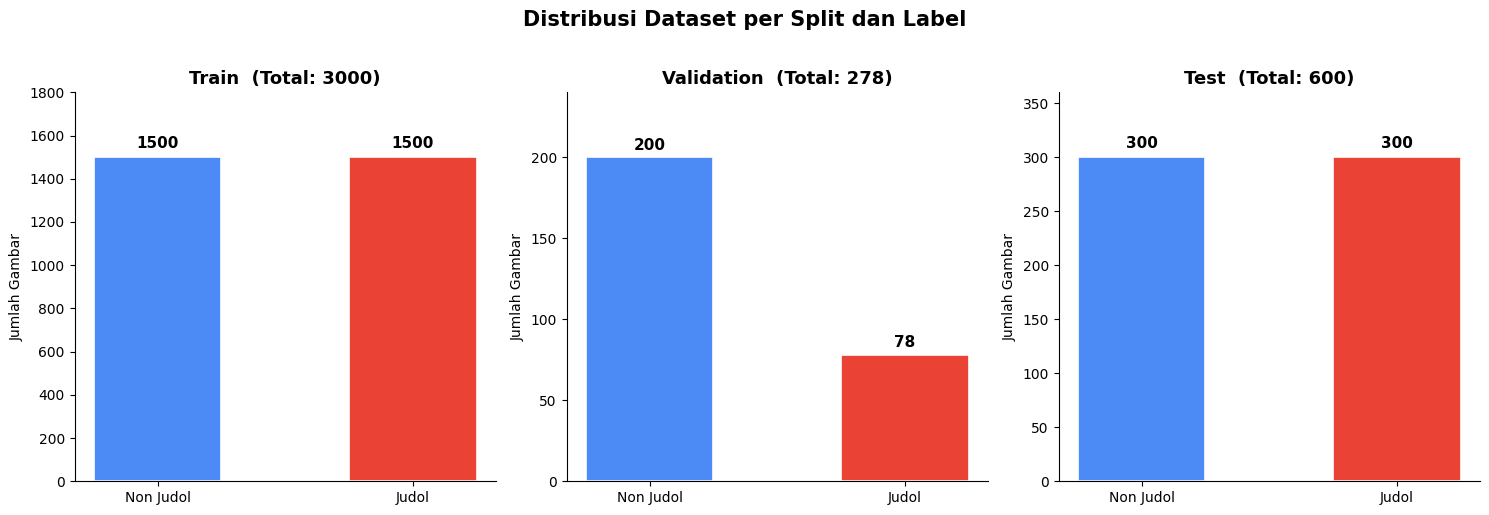

In [5]:
def get_label_counts(dataset):
    labels = [label for _, label in dataset.samples]
    return Counter(labels)

splits = {
    'Train':      train_dataset_raw,
    'Validation': val_dataset_raw,
    'Test':       test_dataset_raw,
}

# --- Tabel teks ---
print(f"{'Split':<12} {'Non Judol (0)':>14} {'Judol (1)':>12} {'Total':>8}")
print('-' * 50)

summary = {}
for split_name, ds in splits.items():
    counts = get_label_counts(ds)
    n0 = counts.get(0, 0)
    n1 = counts.get(1, 0)
    total = n0 + n1
    summary[split_name] = {'Non Judol': n0, 'Judol': n1, 'Total': total}
    print(f"{split_name:<12} {n0:>14} {n1:>12} {total:>8}")

# --- Bar chart distribusi ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#4C8BF5', '#EA4335']

for ax, (split_name, counts) in zip(axes, summary.items()):
    bars = ax.bar(
        ['Non Judol', 'Judol'],
        [counts['Non Judol'], counts['Judol']],
        color=colors,
        edgecolor='white',
        linewidth=1.2,
        width=0.5
    )
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + counts['Total'] * 0.01,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=11, fontweight='bold'
        )
    ax.set_title(f'{split_name}  (Total: {counts["Total"]})', fontsize=13, fontweight='bold')
    ax.set_ylabel('Jumlah Gambar')
    ax.set_ylim(0, max(counts['Non Judol'], counts['Judol']) * 1.2)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Distribusi Dataset per Split dan Label', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Tampilkan 10 Gambar per Label (dari Train Set)

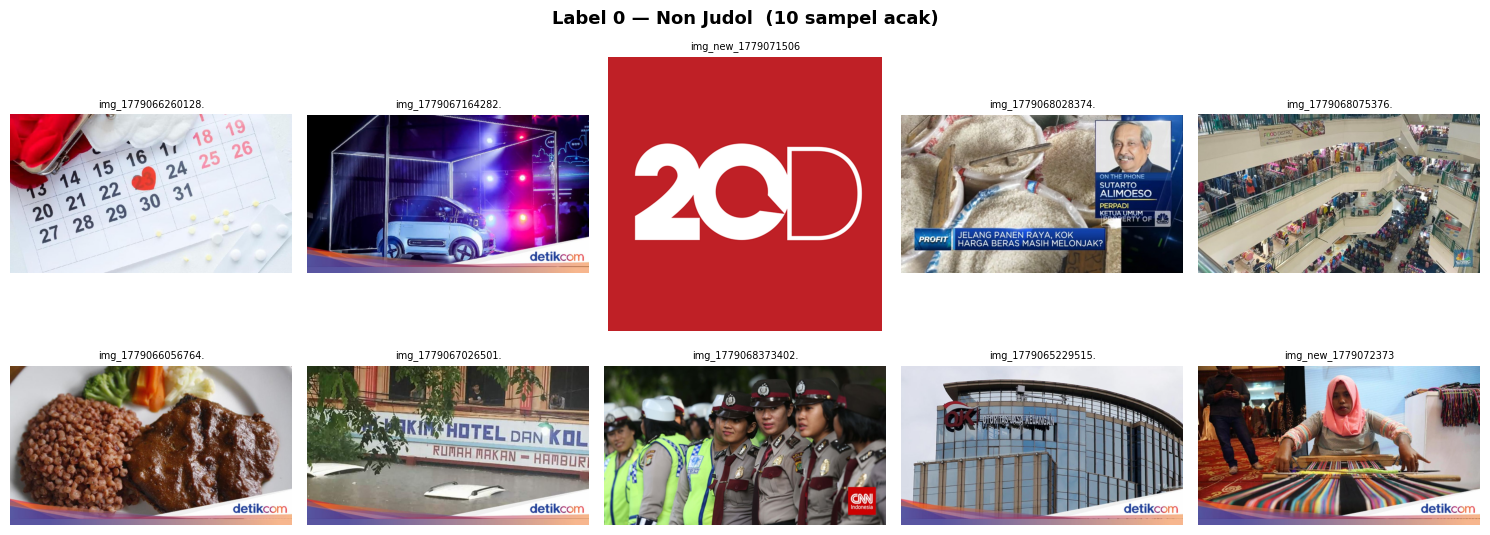

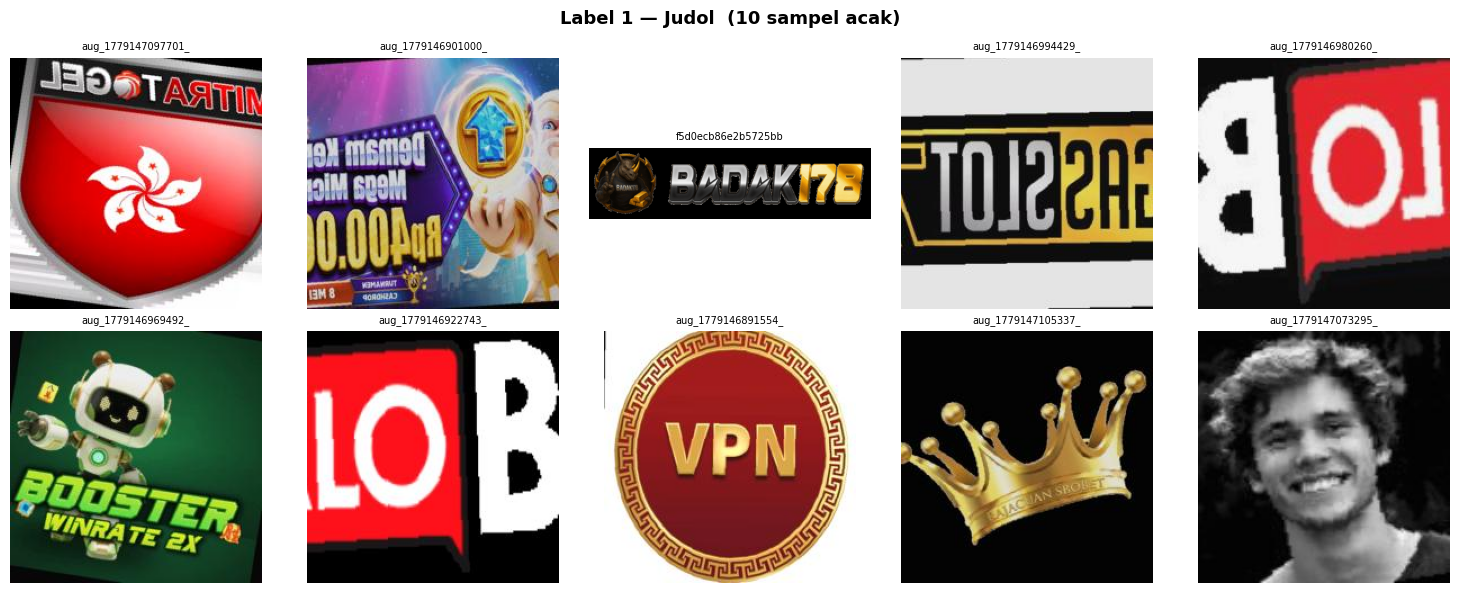

In [6]:
def show_sample_images(dataset, label, label_name, n=10, seed=SEED):
    """Tampilkan n sample gambar dari label tertentu."""
    indices = [i for i, (_, y) in enumerate(dataset.samples) if y == label]

    if len(indices) < n:
        print(f'[WARNING] Hanya ada {len(indices)} gambar untuk label {label_name}, menampilkan semua.')
        n = len(indices)

    random.seed(seed)
    chosen = random.sample(indices, n)

    cols = 5
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()

    for i, (ax, idx) in enumerate(zip(axes, chosen)):
        path, _ = dataset.samples[idx]
        img = Image.open(path).convert('RGB')
        ax.imshow(img)
        ax.set_title(os.path.basename(path)[:18], fontsize=7)
        ax.axis('off')

    # Matikan axes sisa jika n < rows*cols
    for ax in axes[n:]:
        ax.axis('off')

    plt.suptitle(f'Label {label} — {label_name}  ({n} sampel acak)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_sample_images(train_dataset_raw, label=0, label_name='Non Judol')
show_sample_images(train_dataset_raw, label=1, label_name='Judol')

## 7. Transform + Augmentasi (Train Only)


In [7]:
import io

def jpeg_compression(img, quality=85):
    """Simulasi JPEG compression ringan."""
    buffer = io.BytesIO()
    img.save(buffer, format='JPEG', quality=quality)
    buffer.seek(0)
    return Image.open(buffer).convert('RGB')

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0), ratio=(0.95, 1.05)),
    transforms.RandomApply([transforms.Lambda(jpeg_compression)], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print('Transform siap.')


Transform siap.


## 8. Load Dataset dengan Transform Final

In [8]:
train_dataset = MetadataDataset(TRAIN_META, transform=train_transform)
val_dataset   = MetadataDataset(VAL_META,   transform=val_test_transform)
test_dataset  = MetadataDataset(TEST_META,  transform=val_test_transform)

print(f'Train : {len(train_dataset)} gambar')
print(f'Val   : {len(val_dataset)} gambar')
print(f'Test  : {len(test_dataset)} gambar')


Train : 3000 gambar
Val   : 278 gambar
Test  : 600 gambar


## 9. DataLoader

In [9]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 94
Val batches   : 9
Test batches  : 19


## 10. Model ResNet34 Pretrained

In [10]:
model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

num_features = model.fc.in_features
# Ganti ini:
model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_features, 2)
)

model = model.to(device)

print(f'FC layer: in_features={num_features}, out_features=2')
print('Model ready.')

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 170MB/s] 


FC layer: in_features=512, out_features=2
Model ready.


## 11. Loss, Optimizer, Scheduler, Early Stopping

In [11]:
# label_smoothing di sini
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# weight_decay dinaikkan di sini
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-3
)

# Scheduler — JANGAN LUPA INI
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
)

# ES_PATIENCE dinaikkan di sini
EPOCHS          = 20
ES_PATIENCE     = 8
best_val_loss   = float('inf')
es_counter      = 0
BEST_MODEL_PATH = 'best_resnet34.pth'

print('Setup selesai.')

Setup selesai.


## 12. Training Loop

In [12]:
train_losses, val_losses         = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(EPOCHS):

    print(f'\n{'='*55}')
    print(f'Epoch {epoch+1}/{EPOCHS}')
    print(f'{'='*55}')

    # ── TRAIN ──
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_loader)
    train_acc  = accuracy_score(all_labels, all_preds)
    train_f1   = f1_score(all_labels, all_preds, zero_division=0)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ── VALIDATION ──
    model.eval()
    running_val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            running_val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss = running_val_loss / len(val_loader)
    val_acc  = accuracy_score(val_labels, val_preds)
    val_f1   = f1_score(val_labels, val_preds, zero_division=0)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # ── PRINT ──
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Train Loss : {train_loss:.4f}  |  Train Acc : {train_acc:.4f}  |  Train F1 : {train_f1:.4f}')
    print(f'Val Loss   : {val_loss:.4f}  |  Val Acc   : {val_acc:.4f}  |  Val F1   : {val_f1:.4f}')
    print(f'LR         : {current_lr:.6f}')

    # ── SCHEDULER ──
    scheduler.step(val_loss)

    # ── SAVE BEST & EARLY STOPPING ──
    # Ganti kondisi ini:
    if val_loss < best_val_loss - 1e-4:   # tambah min_delta
        best_val_loss = val_loss
        es_counter    = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'✅ Best model saved  (val_loss={best_val_loss:.4f})')
    else:
        es_counter += 1
        print(f'⏳ Early stopping: {es_counter}/{ES_PATIENCE}')
        if es_counter >= ES_PATIENCE:
            print('🛑 Early stopping triggered.')
            break

print('\nTraining selesai.')


Epoch 1/20
Train Loss : 0.3415  |  Train Acc : 0.9250  |  Train F1 : 0.9257
Val Loss   : 0.3166  |  Val Acc   : 0.9424  |  Val F1   : 0.8889
LR         : 0.000100
✅ Best model saved  (val_loss=0.3166)

Epoch 2/20
Train Loss : 0.2610  |  Train Acc : 0.9760  |  Train F1 : 0.9760
Val Loss   : 0.3434  |  Val Acc   : 0.9101  |  Val F1   : 0.8120
LR         : 0.000100
⏳ Early stopping: 1/8

Epoch 3/20
Train Loss : 0.2433  |  Train Acc : 0.9863  |  Train F1 : 0.9863
Val Loss   : 0.3015  |  Val Acc   : 0.9317  |  Val F1   : 0.8633
LR         : 0.000100
✅ Best model saved  (val_loss=0.3015)

Epoch 4/20
Train Loss : 0.2429  |  Train Acc : 0.9907  |  Train F1 : 0.9907
Val Loss   : 0.2740  |  Val Acc   : 0.9568  |  Val F1   : 0.9200
LR         : 0.000100
✅ Best model saved  (val_loss=0.2740)

Epoch 5/20
Train Loss : 0.2264  |  Train Acc : 0.9973  |  Train F1 : 0.9973
Val Loss   : 0.2666  |  Val Acc   : 0.9568  |  Val F1   : 0.9178
LR         : 0.000100
✅ Best model saved  (val_loss=0.2666)

Epoch

## 13. Plot Loss & Accuracy

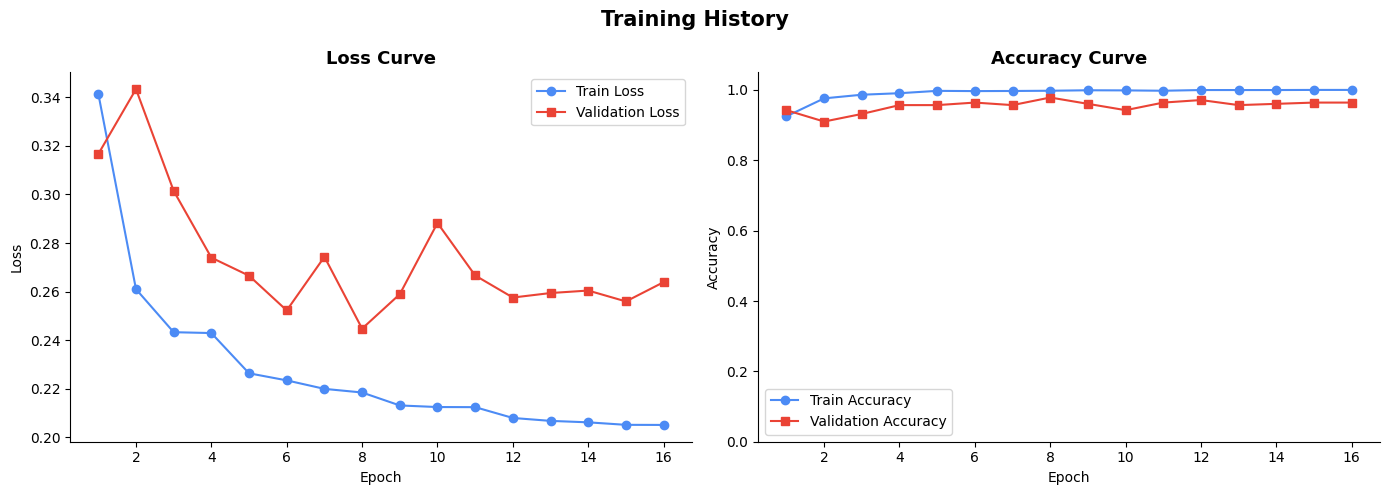

In [13]:
epochs_ran = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_ran, train_losses, 'o-', label='Train Loss',      color='#4C8BF5')
axes[0].plot(epochs_ran, val_losses,   's-', label='Validation Loss', color='#EA4335')
axes[0].set_title('Loss Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Accuracy
axes[1].plot(epochs_ran, train_accuracies, 'o-', label='Train Accuracy',      color='#4C8BF5')
axes[1].plot(epochs_ran, val_accuracies,   's-', label='Validation Accuracy', color='#EA4335')
axes[1].set_title('Accuracy Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Evaluasi pada Test Set

In [14]:
# Load best model
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)   # shape: (B, 2)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())   # list of [p_class0, p_class1]

import numpy as np
all_probs = np.array(all_probs)   # shape: (N, 2)

accuracy  = accuracy_score(all_labels,  all_preds)
precision = precision_score(all_labels, all_preds, zero_division=0)
recall    = recall_score(all_labels,    all_preds, zero_division=0)
f1        = f1_score(all_labels,        all_preds, zero_division=0)
roc_auc   = roc_auc_score(all_labels,   all_probs[:, 1])

print('\n=== TEST RESULT ===')
print(f'Accuracy  : {accuracy:.4f}')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1 Score  : {f1:.4f}')
print(f'ROC AUC   : {roc_auc:.4f}')
print(f'Total test samples dievaluasi: {len(all_preds)}')



=== TEST RESULT ===
Accuracy  : 0.9567
Precision : 0.9567
Recall    : 0.9567
F1 Score  : 0.9567
ROC AUC   : 0.9852
Total test samples dievaluasi: 600


## 15. Classification Report

In [15]:
print(classification_report(
    all_labels, all_preds,
    target_names=['Non Judol', 'Judol']
))

              precision    recall  f1-score   support

   Non Judol       0.96      0.96      0.96       300
       Judol       0.96      0.96      0.96       300

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600



## 16. Confusion Matrix

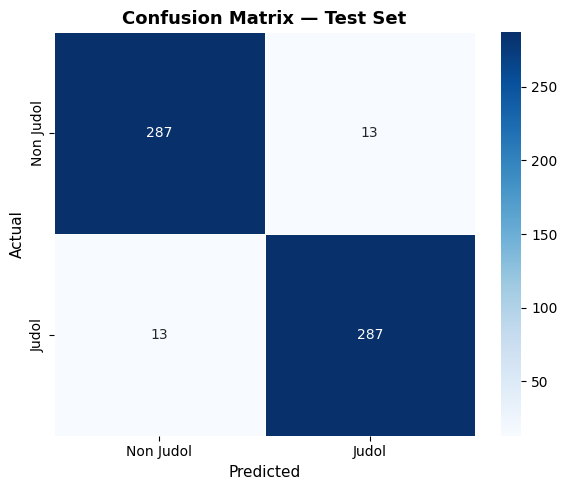

In [16]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non Judol', 'Judol'],
    yticklabels=['Non Judol', 'Judol'],
    linewidths=0.5,
    linecolor='white'
)
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('Actual',    fontsize=11)
plt.title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 17. Softmax Confidence Distribution


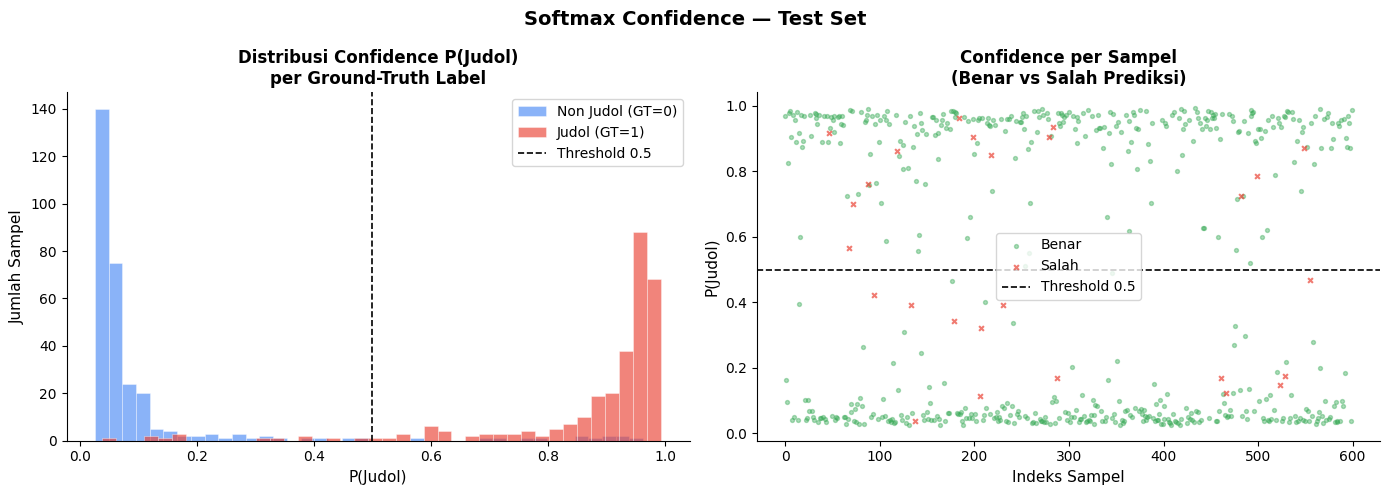


── Statistik P(Judol) ──
  Non Judol  → mean=0.105  std=0.169  min=0.026  max=0.962
  Judol      → mean=0.882  std=0.168  min=0.038  max=0.993


In [17]:
# ── Distribusi confidence (probabilitas kelas Judol) ──
probs_judol     = all_probs[:, 1]           # P(Judol) untuk tiap sampel
probs_non_judol = all_probs[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histogram confidence per kelas sesungguhnya ---
for true_label, color, name in [(0, '#4C8BF5', 'Non Judol (GT=0)'),
                                   (1, '#EA4335', 'Judol (GT=1)')]:
    mask = np.array(all_labels) == true_label
    axes[0].hist(
        probs_judol[mask], bins=40, alpha=0.65,
        color=color, label=name, edgecolor='white', linewidth=0.4
    )

axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Threshold 0.5')
axes[0].set_xlabel('P(Judol)', fontsize=11)
axes[0].set_ylabel('Jumlah Sampel', fontsize=11)
axes[0].set_title('Distribusi Confidence P(Judol)\nper Ground-Truth Label', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].spines[['top', 'right']].set_visible(False)

# --- Scatter: confidence vs prediksi (benar/salah) ---
all_labels_arr = np.array(all_labels)
all_preds_arr  = np.array(all_preds)
correct_mask   = all_labels_arr == all_preds_arr

axes[1].scatter(
    np.arange(len(probs_judol))[correct_mask],
    probs_judol[correct_mask],
    s=8, alpha=0.4, color='#34A853', label='Benar'
)
axes[1].scatter(
    np.arange(len(probs_judol))[~correct_mask],
    probs_judol[~correct_mask],
    s=12, alpha=0.7, color='#EA4335', label='Salah', marker='x'
)
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1.2, label='Threshold 0.5')
axes[1].set_xlabel('Indeks Sampel', fontsize=11)
axes[1].set_ylabel('P(Judol)', fontsize=11)
axes[1].set_title('Confidence per Sampel\n(Benar vs Salah Prediksi)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Softmax Confidence — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Ringkasan statistik confidence ---
print('\n── Statistik P(Judol) ──')
for true_label, name in [(0, 'Non Judol'), (1, 'Judol')]:
    mask = all_labels_arr == true_label
    p    = probs_judol[mask]
    print(f'  {name:10s} → mean={p.mean():.3f}  std={p.std():.3f}'
          f'  min={p.min():.3f}  max={p.max():.3f}')


## 18. ROC Curve & AUC


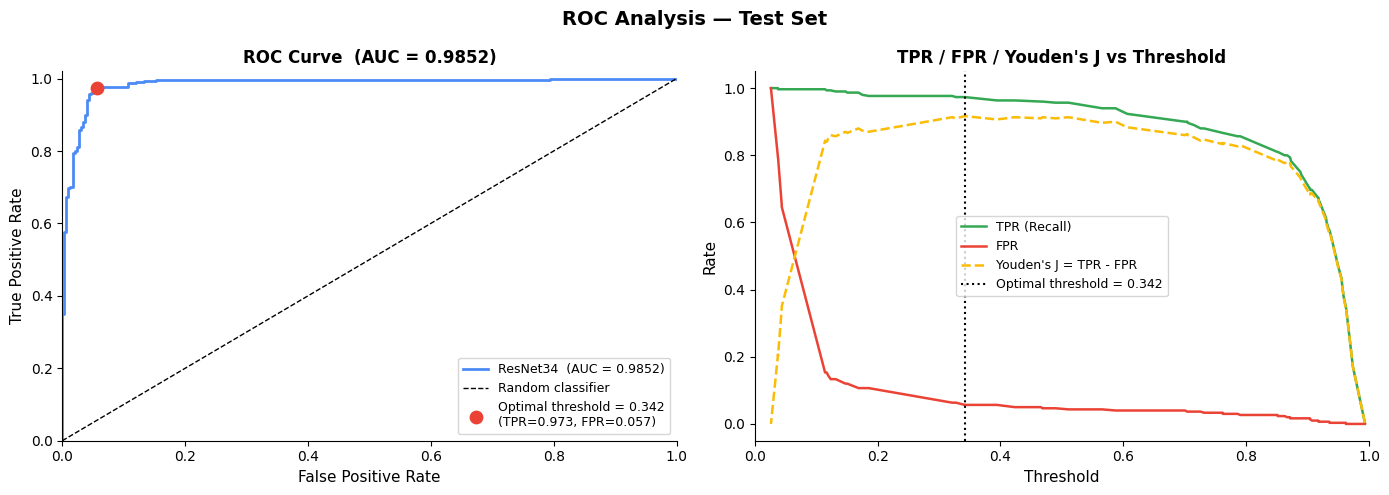


ROC AUC Score    : 0.9852
Optimal Threshold: 0.3419  (Youden J = 0.9167)
  → TPR (Recall) @ optimal : 0.9733
  → FPR           @ optimal : 0.0567

── Hasil dengan Optimal Threshold (0.3419) ──
  Accuracy  : 0.9583
  Precision : 0.9450
  Recall    : 0.9733
  F1 Score  : 0.9589


In [18]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs[:, 1])

# ── Cari threshold optimal (Youden's J = TPR - FPR) ──
j_scores     = tpr - fpr
best_idx     = np.argmax(j_scores)
best_thresh  = thresholds[best_idx]
best_fpr     = fpr[best_idx]
best_tpr     = tpr[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC Curve ---
axes[0].plot(fpr, tpr, color='#4C8BF5', linewidth=2,
             label=f'ResNet34  (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
axes[0].scatter(best_fpr, best_tpr, color='#EA4335', s=80, zorder=5,
                label=f'Optimal threshold = {best_thresh:.3f}\n'
                       f'(TPR={best_tpr:.3f}, FPR={best_fpr:.3f})')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title(f'ROC Curve  (AUC = {roc_auc:.4f})', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9, loc='lower right')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])
axes[0].spines[['top', 'right']].set_visible(False)

# --- Youden's J vs Threshold ---
axes[1].plot(thresholds, tpr[:-1] if len(thresholds) < len(tpr) else tpr,
             color='#34A853', linewidth=1.8, label='TPR (Recall)')
axes[1].plot(thresholds, fpr[:-1] if len(thresholds) < len(fpr) else fpr,
             color='#EA4335', linewidth=1.8, label='FPR')
axes[1].plot(thresholds, j_scores[:-1] if len(thresholds) < len(j_scores) else j_scores,
             color='#FBBC05', linewidth=1.8, linestyle='--', label="Youden's J = TPR - FPR")
axes[1].axvline(best_thresh, color='black', linestyle=':', linewidth=1.5,
                label=f'Optimal threshold = {best_thresh:.3f}')
axes[1].set_xlabel('Threshold', fontsize=11)
axes[1].set_ylabel('Rate', fontsize=11)
axes[1].set_title("TPR / FPR / Youden's J vs Threshold", fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlim([0, 1])
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('ROC Analysis — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nROC AUC Score    : {roc_auc:.4f}')
print(f'Optimal Threshold: {best_thresh:.4f}  (Youden J = {j_scores[best_idx]:.4f})')
print(f'  → TPR (Recall) @ optimal : {best_tpr:.4f}')
print(f'  → FPR           @ optimal : {best_fpr:.4f}')

# ── Evaluasi ulang dengan threshold optimal ──
preds_opt  = (all_probs[:, 1] >= best_thresh).astype(int)
acc_opt    = accuracy_score(all_labels,  preds_opt)
prec_opt   = precision_score(all_labels, preds_opt, zero_division=0)
rec_opt    = recall_score(all_labels,    preds_opt, zero_division=0)
f1_opt     = f1_score(all_labels,        preds_opt, zero_division=0)

print(f'\n── Hasil dengan Optimal Threshold ({best_thresh:.4f}) ──')
print(f'  Accuracy  : {acc_opt:.4f}')
print(f'  Precision : {prec_opt:.4f}')
print(f'  Recall    : {rec_opt:.4f}')
print(f'  F1 Score  : {f1_opt:.4f}')


## 19. Simpan Model Final


In [19]:
torch.save(model.state_dict(), 'final_resnet34_judol.pth')
print('Model final tersimpan: final_resnet34_judol.pth')
print('Download via: Right Sidebar → Output → Download')

Model final tersimpan: final_resnet34_judol.pth
Download via: Right Sidebar → Output → Download
